## Baseline — HistGradientBoosting (3-Class)

Baseline đơn giản để so sánh với model HistGradientBoosting đã tune (`modeling.ipynb`).

- Giữ nguyên 3 lớp gốc: **Fail / Pass / Withdrawn** (không gộp At-risk)
- **Không SMOTE, không class weight, không Bayesian Optimization, không scaling** (HistGradientBoosting bất biến với scaling) — chỉ train `HistGradientBoostingClassifier` mặc định
- Mỗi `prediction_point` train một model riêng
- **Metric**: Precision / Recall / F1 theo từng lớp, ROC-AUC (macro, one-vs-rest), Confusion Matrix, Classification Report

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED, SNAPSHOTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import label_binarize
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, roc_curve,
)

In [8]:
data_dir = Path('../data/processed')

X_train    = pd.read_parquet(data_dir / 'X_train.parquet')
X_test     = pd.read_parquet(data_dir / 'X_test.parquet')
y_train    = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test     = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

TARGET_NAMES = ['Fail', 'Pass', 'Withdrawn']
CLASSES = [0, 1, 2]

print('X_train:', X_train.shape)
print('Features:', list(X_train.columns))
print('Snapshots:', sorted(train_meta['prediction_point'].unique()))
print('Phân phối nhãn (train):', y_train.value_counts().to_dict())

X_train: (142384, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Snapshots: [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(150), np.int64(180), np.int64(210), np.int64(240)]
Phân phối nhãn (train): {1: 88536, 0: 40333, 2: 13515}


### Helper functions

In [9]:
def get_snapshot_data(T):
    mask_tr = train_meta['prediction_point'].values == T
    mask_te = test_meta['prediction_point'].values == T
    return (
        X_train[mask_tr].reset_index(drop=True),
        X_test[mask_te].reset_index(drop=True),
        y_train[mask_tr].reset_index(drop=True),
        y_test[mask_te].reset_index(drop=True),
    )


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — tất cả prediction_point

Với mỗi mốc T:
1. Lấy train/test theo `prediction_point`, fillna(0)
2. `HistGradientBoostingClassifier` mặc định (không tune hyperparameter), train trên train
3. Evaluate trên test: classification report, confusion matrix, ROC-AUC macro (one-vs-rest)


############################################################
  PREDICTION POINT = 30 days
############################################################
Train: 19,988 | Test: 5,043

  T=30
              precision    recall  f1-score   support

        Fail      0.486     0.360     0.414      1274
        Pass      0.678     0.905     0.775      2804
   Withdrawn      0.497     0.181     0.266       965

    accuracy                          0.629      5043
   macro avg      0.554     0.482     0.485      5043
weighted avg      0.595     0.629     0.586      5043



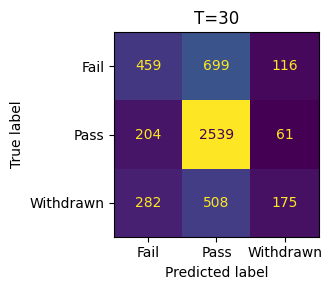


############################################################
  PREDICTION POINT = 60 days
############################################################
Train: 19,123 | Test: 4,835

  T=60
              precision    recall  f1-score   support

        Fail      0.546     0.492     0.518      1274
        Pass      0.729     0.914     0.811      2804
   Withdrawn      0.506     0.116     0.189       757

    accuracy                          0.678      4835
   macro avg      0.594     0.507     0.506      4835
weighted avg      0.646     0.678     0.636      4835



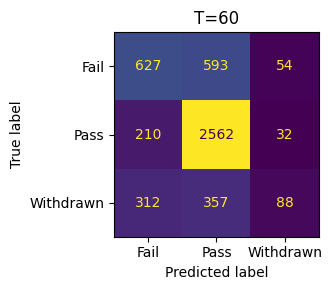


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680

  T=90
              precision    recall  f1-score   support

        Fail      0.587     0.551     0.568      1274
        Pass      0.762     0.924     0.836      2804
   Withdrawn      0.417     0.058     0.102       602

    accuracy                          0.711      4680
   macro avg      0.589     0.511     0.502      4680
weighted avg      0.670     0.711     0.669      4680



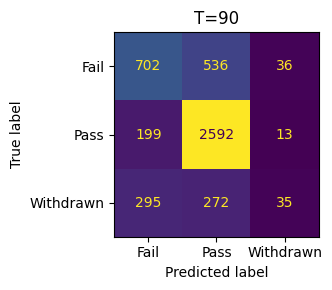


############################################################
  PREDICTION POINT = 120 days
############################################################
Train: 17,917 | Test: 4,518

  T=120
              precision    recall  f1-score   support

        Fail      0.641     0.615     0.627      1274
        Pass      0.805     0.931     0.864      2804
   Withdrawn      0.426     0.052     0.093       440

    accuracy                          0.756      4518
   macro avg      0.624     0.533     0.528      4518
weighted avg      0.722     0.756     0.722      4518



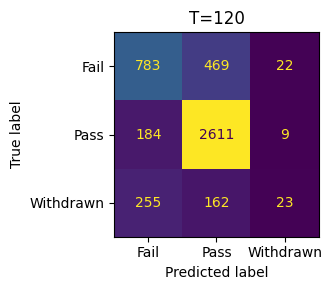


############################################################
  PREDICTION POINT = 150 days
############################################################
Train: 17,386 | Test: 4,363

  T=150
              precision    recall  f1-score   support

        Fail      0.717     0.692     0.704      1274
        Pass      0.848     0.940     0.892      2804
   Withdrawn      0.273     0.021     0.039       285

    accuracy                          0.808      4363
   macro avg      0.612     0.551     0.545      4363
weighted avg      0.772     0.808     0.781      4363



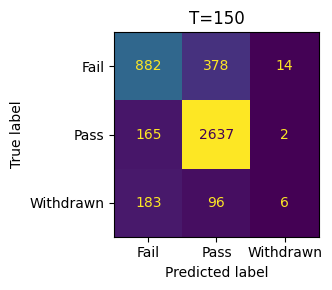


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215

  T=180
              precision    recall  f1-score   support

        Fail      0.790     0.731     0.759      1274
        Pass      0.874     0.946     0.909      2804
   Withdrawn      0.000     0.000     0.000       137

    accuracy                          0.850      4215
   macro avg      0.555     0.559     0.556      4215
weighted avg      0.820     0.850     0.834      4215



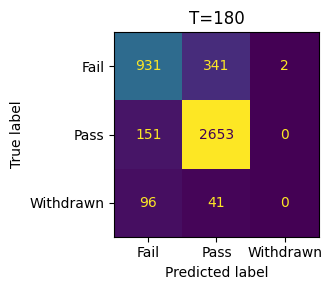


############################################################
  PREDICTION POINT = 210 days
############################################################
Train: 16,486 | Test: 4,162

  T=210
              precision    recall  f1-score   support

        Fail      0.821     0.747     0.783      1274
        Pass      0.886     0.947     0.915      2804
   Withdrawn      0.500     0.048     0.087        84

    accuracy                          0.867      4162
   macro avg      0.736     0.580     0.595      4162
weighted avg      0.859     0.867     0.858      4162



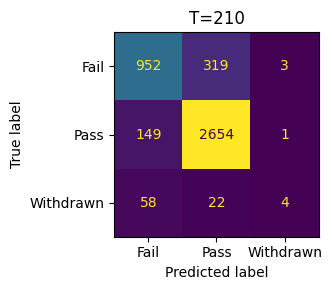


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094

  T=240
              precision    recall  f1-score   support

        Fail      0.870     0.766     0.815      1274
        Pass      0.901     0.953     0.926      2804
   Withdrawn      0.143     0.062     0.087        16

    accuracy                          0.891      4094
   macro avg      0.638     0.594     0.609      4094
weighted avg      0.888     0.891     0.888      4094



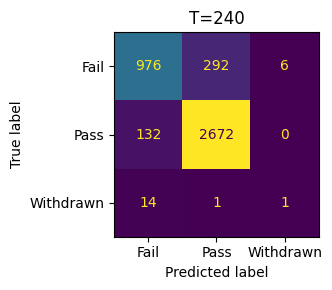


--- Tổng hợp ---


,prediction_point,accuracy,recall_fail,recall_pass,recall_withdrawn,precision_fail,precision_withdrawn,f1_fail,f1_withdrawn,f1_macro,roc_auc_macro
0,30,0.6292,0.3603,0.9055,0.1813,0.4857,0.4972,0.4137,0.2658,0.4849,0.7384
1,60,0.6778,0.4922,0.9137,0.1162,0.5457,0.5057,0.5175,0.1890,0.5060,0.7693
2,90,0.7113,0.5510,0.9244,0.0581,0.5870,0.4167,0.5684,0.1020,0.5020,0.7963
3,120,0.7563,0.6146,0.9312,0.0523,0.6408,0.4259,0.6274,0.0931,0.5281,0.8243
4,150,0.8079,0.6923,0.9404,0.0211,0.7171,0.2727,0.7045,0.0391,0.5451,0.8492
5,180,0.8503,0.7308,0.9461,0.0000,0.7903,0.0000,0.7594,0.0000,0.5560,0.8686
6,210,0.8674,0.7473,0.9465,0.0476,0.8214,0.5000,0.7826,0.0870,0.5950,0.8907
7,240,0.8913,0.7661,0.9529,0.0625,0.8699,0.1429,0.8147,0.0870,0.6093,0.9346


In [10]:
models   = {}
roc_data = {}  # roc_data[T][class] = (fpr, tpr, auc)
results  = []

for T in SNAPSHOTS:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    model = HistGradientBoostingClassifier(random_state=RANDOM_SEED)
    model.fit(X_tr, y_tr)

    models[T] = model

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)  # shape (N, 3), columns theo model.classes_

    evaluate_full(f'T={T}', y_te, y_pred)

    # ROC curve one-vs-rest cho từng lớp
    y_te_bin = label_binarize(y_te, classes=CLASSES)
    roc_data[T] = {}
    for ci, c in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_te_bin[:, ci], y_proba[:, ci])
        roc_data[T][c] = (fpr, tpr)

    roc_auc_macro = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro', labels=CLASSES)

    recalls    = recall_score(y_te, y_pred, average=None, labels=CLASSES, zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=CLASSES, zero_division=0)
    f1s        = f1_score(y_te, y_pred, average=None, labels=CLASSES, zero_division=0)

    results.append({
        'prediction_point':     T,
        'accuracy':             round(accuracy_score(y_te, y_pred), 4),
        'recall_fail':          round(recalls[0], 4),
        'recall_pass':          round(recalls[1], 4),
        'recall_withdrawn':     round(recalls[2], 4),
        'precision_fail':       round(precisions[0], 4),
        'precision_withdrawn':  round(precisions[2], 4),
        'f1_fail':              round(f1s[0], 4),
        'f1_withdrawn':         round(f1s[2], 4),
        'f1_macro':             round(f1s.mean(), 4),
        'roc_auc_macro':        round(roc_auc_macro, 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df